# Clasificación de sentimientos mediante TF-IDF y SVM lineal

## 1. Introducción

En este notebook se desarrolla un clasificador de sentimientos basado en Máquinas de Soporte Vectorial con kernel lineal (`LinearSVC`), como parte de la comparación de modelos clásicos realizada por el equipo para la Parte 1 de la competencia.

El punto de partida es la mejor representación encontrada en el notebook de Regresión Logística (modelo V2): la última oración de cada reseña representada mediante TF-IDF de palabras (unigramas y bigramas) y de caracteres (secuencias de tres a cinco caracteres). Esa configuración obtuvo una accuracy promedio de 85,36% en validación cruzada y un puntaje público de 86,56% en Kaggle.

Una SVM lineal busca el hiperplano que separa las clases con el mayor margen posible. Este tipo de modelo suele funcionar bien con representaciones de texto dispersas y de alta dimensionalidad como TF-IDF, ya que en esos espacios las clases tienden a ser aproximadamente separables de forma lineal. Para el caso multiclase, `LinearSVC` entrena un clasificador por clase (esquema uno contra el resto).

El desarrollo seguirá la misma estructura de las prácticas del curso: carga y partición de los datos, construcción del pipeline, búsqueda de hiperparámetros con validación cruzada, evaluación, análisis de errores, persistencia del modelo y generación de predicciones para Kaggle.

Para que los resultados sean comparables con los demás modelos del equipo se mantiene la misma partición estratificada (80% entrenamiento, 20% validación, `random_state=42`) y la misma estrategia de validación cruzada estratificada de cinco particiones.

## 2. Importación de librerías

Se utilizarán pandas y NumPy para el manejo de datos y Matplotlib para las visualizaciones.

De scikit-learn se emplearán `TfidfVectorizer` para la representación de texto, `FeatureUnion` para combinar varias representaciones, `FunctionTransformer` para incorporar las transformaciones propias del texto dentro del pipeline y `LinearSVC` como clasificador. La búsqueda de hiperparámetros se realizará con `GridSearchCV` y `StratifiedKFold`.

Las funciones de transformación del texto se encuentran en el módulo `transformaciones.py` de la raíz del proyecto. Mantenerlas en un módulo, y no definidas dentro del notebook, permite que el pipeline almacenado con `joblib` pueda cargarse posteriormente desde cualquier entorno que tenga acceso a ese archivo.

In [1]:
import sys
import importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Identificar la carpeta del proyecto
raiz = Path.cwd().resolve()

if raiz.name == "notebooks":
    raiz = raiz.parent

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

# Importar las transformaciones del proyecto
import transformaciones
importlib.reload(transformaciones)

from transformaciones import extraer_oraciones_lote, marcar_conectores_lote

print("Librerías y transformaciones importadas correctamente")

Librerías y transformaciones importadas correctamente


## 3. Carga y partición de los datos

Se utilizará el conjunto de entrenamiento de la competencia, con 12.000 reseñas etiquetadas como positivas, negativas o neutrales, y el conjunto de evaluación de Kaggle, con 3.000 reseñas sin etiqueta.

La partición se realiza de forma estratificada y con la misma semilla aleatoria empleada por el equipo, de manera que los 2.400 registros de validación sean exactamente los mismos que se utilizaron para evaluar los demás modelos.

El conjunto de evaluación de Kaggle no se utilizará para entrenar ni para seleccionar hiperparámetros. Solo se empleará al final para generar las predicciones del envío.

In [2]:
# Ubicación de los archivos
data_dir = raiz / "data"

# Cargar los datos
train = pd.read_csv(data_dir / "train.csv")
eval_data = pd.read_csv(data_dir / "eval.csv")
sample = pd.read_csv(data_dir / "sample_submission.csv")

# Separar variables
X = train["text"]
y = train["label"]

# División de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", len(X_train))
print("Datos de validación:", len(X_val))
print("Datos de evaluación (Kaggle):", len(eval_data))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

Datos de entrenamiento: 9600
Datos de validación: 2400
Datos de evaluación (Kaggle): 3000

Distribución en entrenamiento:
label
positivo    0.351
negativo    0.351
neutral     0.298
Name: proportion, dtype: float64


## 4. Modelo base: SVM lineal con la representación V2

Como primer experimento se reemplaza la Regresión Logística del modelo V2 por una SVM lineal, manteniendo exactamente la misma representación del texto:

1. Extracción de la última oración de cada reseña, mediante la función `extraer_oraciones_lote` del módulo de transformaciones.
2. TF-IDF de palabras con unigramas y bigramas, frecuencia documental mínima de 2 y frecuencia sublineal (`sublinear_tf=True`).
3. TF-IDF de caracteres con secuencias de tres a cinco caracteres y los mismos parámetros.

Las dos representaciones se combinan mediante `FeatureUnion`. Así, si hay diferencias de desempeño frente a V2, se deben al clasificador y no a la representación.

El hiperparámetro principal de `LinearSVC` es `C`, que controla la regularización de forma análoga a la Regresión Logística: valores pequeños producen un margen más amplio y un modelo más regularizado, mientras que valores grandes intentan clasificar correctamente más ejemplos de entrenamiento, con mayor riesgo de sobreajuste. Se usa `max_iter=5000` para que el optimizador alcance a converger.

In [3]:
# Representación del modelo V2: última oración, palabras y caracteres
representacion_v2 = FeatureUnion([
    (
        "palabras",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "caracteres",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True
        )
    )
])

pipeline_svm_base = Pipeline([
    (
        "extraer_oracion",
        FunctionTransformer(
            extraer_oraciones_lote,
            kw_args={"cantidad": 1},
            validate=False
        )
    ),
    (
        "representacion",
        representacion_v2
    ),
    (
        "modelo",
        LinearSVC(
            max_iter=5000,
            random_state=42
        )
    )
])

pipeline_svm_base

Pipeline(steps=[('extraer_oracion',
                 FunctionTransformer(func=<function extraer_oraciones_lote at 0x00000282978C5AF0>,
                                     kw_args={'cantidad': 1})),
                ('representacion',
                 FeatureUnion(transformer_list=[('palabras',
                                                 TfidfVectorizer(min_df=2,
                                                                 ngram_range=(1,
                                                                              2),
                                                                 sublinear_tf=True)),
                                                ('caracteres',
                                                 TfidfVectorizer(analyzer='char',
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5),
                                                                 sublinear_tf=True))])),
                ('modelo', LinearSVC(max_iter=5000, random_state=42))])

### 4.1. Búsqueda de hiperparámetros del modelo base

Se realizará una búsqueda mediante `GridSearchCV` sobre dos hiperparámetros:

- `C`: valores entre 0,05 y 1, en una escala que permite observar el efecto de la regularización.
- `class_weight`: sin ponderación (`None`) o con ponderación balanceada (`'balanced'`). En la descripción de la competencia se menciona que la clase `neutral` es algo menos frecuente que `positivo` y `negativo`. Siguiendo lo visto en la práctica de Random Forest, `class_weight='balanced'` asigna a cada clase un peso inversamente proporcional a su frecuencia, sin generar datos sintéticos.

La métrica de selección es la accuracy, por ser la métrica de evaluación de la competencia. Como el desbalance es leve (35%, 35% y 30%), esta métrica no resulta engañosa en este caso. Aun así, se revisará el desempeño por clase en la evaluación.

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid_base = {
    "modelo__C": [0.05, 0.1, 0.2, 0.5, 1],
    "modelo__class_weight": [None, "balanced"]
}

grid_base = GridSearchCV(
    estimator=pipeline_svm_base,
    param_grid=param_grid_base,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_base.fit(X_train, y_train)

print("Mejores parámetros:", grid_base.best_params_)
print(f"Accuracy promedio en CV: {grid_base.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Mejores parámetros: {'modelo__C': 0.2, 'modelo__class_weight': 'balanced'}
Accuracy promedio en CV: 0.8595


In [5]:
resultados_base = pd.DataFrame(grid_base.cv_results_)

cols = [
    "param_modelo__C",
    "param_modelo__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

display(resultados_base[cols].sort_values("rank_test_score"))

,param_modelo__C,param_modelo__class_weight,mean_test_score,std_test_score,rank_test_score
5,0.20,balanced,0.859479,0.008510,1
4,0.20,None,0.859479,0.008561,2
2,0.10,None,0.859167,0.008524,3
3,0.10,balanced,0.858958,0.009048,4
7,0.50,balanced,0.858646,0.009332,5
6,0.50,None,0.858542,0.009180,6
9,1.00,balanced,0.856250,0.006267,7
8,1.00,None,0.855729,0.006839,8
1,0.05,balanced,0.854375,0.011376,9
0,0.05,None,0.854063,0.010671,10


### 4.2. Resultados del modelo base

Se evaluaron 10 configuraciones mediante validación cruzada estratificada de cinco particiones, para un total de 50 ajustes.

La mejor configuración utilizó `C=0.2`, con una accuracy promedio de 85,95%. Este resultado supera en aproximadamente 0,6 puntos porcentuales al 85,36% obtenido por la Regresión Logística V2 con la misma representación y las mismas particiones.

La ponderación de clases prácticamente no modificó el desempeño: con `C=0.2`, ambas variantes obtuvieron 85,95%, y en general las diferencias entre `None` y `'balanced'` fueron inferiores a 0,1 puntos porcentuales. Esto es coherente con el desbalance leve del conjunto de datos. La búsqueda seleccionó `class_weight='balanced'`, pero la diferencia con `None` en la accuracy promedio es despreciable.

Respecto a la regularización, los valores intermedios de `C` (0,1 a 0,5) obtuvieron los mejores resultados. Con `C=0.05` el modelo queda demasiado regularizado (85,44%) y con `C=1` el desempeño también disminuye (85,62%), lo que sugiere un inicio de sobreajuste.

## 5. Evaluación del modelo base en validación

Se evaluará el mejor pipeline encontrado sobre las 2.400 reseñas reservadas para validación, que no participaron en el entrenamiento ni en la búsqueda de hiperparámetros.

Accuracy en validación: 0.8729

              precision    recall  f1-score   support

    negativo     0.8384    0.8493    0.8438       843
     neutral     0.9080    0.9804    0.9428       715
    positivo     0.8760    0.8052    0.8391       842

    accuracy                         0.8729      2400
   macro avg     0.8741    0.8783    0.8753      2400
weighted avg     0.8723    0.8729    0.8717      2400



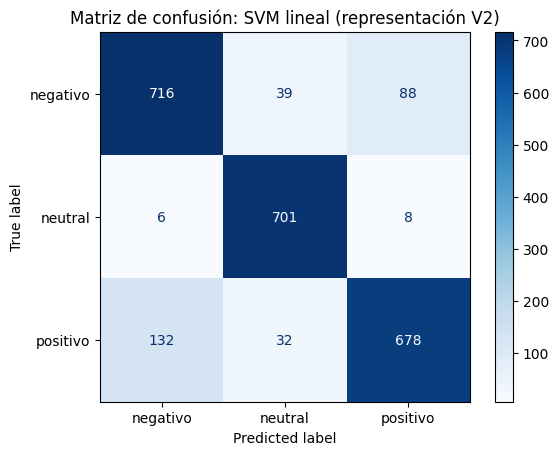

In [6]:
mejor_base = grid_base.best_estimator_

y_pred_base = mejor_base.predict(X_val)

print(f"Accuracy en validación: {accuracy_score(y_val, y_pred_base):.4f}\n")
print(classification_report(y_val, y_pred_base, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_base, cmap="Blues")
plt.title("Matriz de confusión: SVM lineal (representación V2)")
plt.show()

### 5.1. Interpretación de los resultados del modelo base

El modelo base obtuvo una accuracy de 87,29% sobre las 2.400 reseñas de validación, valor cercano al 85,95% de la validación cruzada.

La clase `neutral` es la que mejor se clasifica, con un F1-score de 0,94 y un recall de 0,98. Las clases `negativo` y `positivo` obtuvieron F1-scores de 0,84. Como en los modelos anteriores del equipo, la principal dificultad sigue siendo distinguir entre reseñas positivas y negativas: la mayoría de los errores de la matriz de confusión corresponden a confusiones entre estas dos clases.

## 6. Análisis de errores

Para entender qué limita al modelo, se obtienen predicciones fuera de muestra sobre el conjunto de entrenamiento mediante `cross_val_predict`. Cada reseña se predice con un modelo que no la vio durante el ajuste, por lo que se pueden revisar los errores sin utilizar el conjunto de validación.

In [7]:
pred_cv_base = cross_val_predict(
    mejor_base,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

errores = pd.DataFrame({
    "text": X_train,
    "real": y_train,
    "predicho": pred_cv_base
})
errores = errores[errores["real"] != errores["predicho"]]

print("Errores en validación cruzada:", len(errores), "de", len(X_train))

display(pd.crosstab(errores["real"], errores["predicho"]))

Errores en validación cruzada: 1349 de 9600


predicho,negativo,neutral,positivo
real,,,
negativo,0,159,436
neutral,14,0,32
positivo,525,183,0


In [8]:
# Muestra de reseñas positivas y negativas confundidas entre sí
pd.set_option("display.max_colwidth", None)

muestra_errores = errores[
    errores["real"].isin(["positivo", "negativo"]) &
    errores["predicho"].isin(["positivo", "negativo"])
].sample(8, random_state=1)

for _, fila in muestra_errores.iterrows():
    print(f"[real={fila['real']} | predicho={fila['predicho']}]")
    print(fila["text"])
    print()

[real=negativo | predicho=positivo]
Me llego el paquete a mitad de semana, dos dias despues de pedirlo, y venia bien embalado con sus manuales y demas. Lo compre para el cuarto de invitados mas que nada, por una mudanza que hicimos en marzo. La app del fabricante me dio mas de un dolor de cabeza, la verdad, y la bateria fue todo un acierto. Cada quien que juzgue.

[real=negativo | predicho=positivo]
Lo compre a mediados de mes por internet y llego en cuatro dias, asi que ahi no hubo problema. Llevo varias semanas usandolo casi a diario y lo estoy probando a fondo en distintas situaciones. El peso se dano antes de lo que esperaba. Por otro lado, recomiendo la relacion calidad-precio con los ojos cerrados.

[real=positivo | predicho=negativo]
Llevo ya un buen rato con esta máquina, la pruebo casi todos los días en la cocina después del trabajo, me llegó a los cuatro días de pedirla. La neta el motor no vale lo que cuesta. Además, me alegra haber elegido el empaque, porque venía bien pues

### 6.1. Interpretación del análisis de errores

Al revisar las reseñas mal clasificadas se observa un patrón que se repite: muchas reseñas tienen dos opiniones opuestas sobre distintos aspectos del producto, y el sentimiento global parece depender de la expresión con la que se introduce cada opinión, no solo de su posición en el texto.

- Expresiones como "Eso sí,", "Por cierto,", "De paso," o "Por otro lado," suelen introducir un comentario secundario. En muchas de estas reseñas el sentimiento global corresponde a la opinión anterior, aunque la secundaria esté más cerca del final.
- Muchas reseñas terminan con frases sin carga de sentimiento ("Cada quien que juzgue", "No sabría bien qué recomendar"). En esos casos la última oración no contiene la opinión que define la etiqueta.
- Estos patrones no se cumplen siempre: también hay reseñas en las que la opinión introducida por uno de estos conectores sí coincide con la etiqueta. Por eso no se escribieron reglas manuales, sino que se le da al modelo esta información para que aprenda su peso a partir de los datos.

Esto explica por qué el modelo que solo observa la última oración falla en las reseñas con opiniones mixtas. Además, coincide con lo que plantea el enunciado del proyecto: el sentimiento global depende del orden y de los conectores contrastivos, y esa información se pierde en una bolsa de palabras convencional.

Para comprobarlo, se compara qué tan frecuentes son algunas de estas expresiones en las reseñas mal clasificadas y en el total.

In [9]:
expresiones = ["eso sí", "por cierto", "de paso", "por otro lado",
               "en cambio", "sin embargo", "al final"]

texto_train = X_train.str.lower()
texto_errores = errores["text"].str.lower()

presencia = pd.DataFrame({
    "Expresión": expresiones,
    "% en todas las reseñas": [texto_train.str.contains(e).mean() * 100 for e in expresiones],
    "% en reseñas mal clasificadas": [texto_errores.str.contains(e).mean() * 100 for e in expresiones]
}).round(2)

display(presencia)

,Expresión,% en todas las reseñas,% en reseñas mal clasificadas
0,eso sí,9.44,11.64
1,por cierto,5.84,7.56
2,de paso,5.29,7.26
3,por otro lado,6.19,14.16
4,en cambio,0.26,0.96
5,sin embargo,1.00,2.15
6,al final,9.91,6.30


### 6.2. Interpretación de la presencia de conectores

Las expresiones que introducen comentarios secundarios están sobrerrepresentadas en las reseñas mal clasificadas. El caso más marcado es "por otro lado", presente en el 6,19% del total de reseñas pero en el 14,16% de los errores, es decir, más del doble. También aumentan "por cierto" (5,84% frente a 7,56%), "de paso" (5,29% frente a 7,26%) y "eso sí" (9,44% frente a 11,64%).

En cambio, "al final" aparece con menor frecuencia en los errores (6,30%) que en el total (9,91%). Una posible explicación es que, cuando la última oración comienza con esta expresión, suele contener la valoración que define la etiqueta, y el modelo base ya se fija en esa oración.

Estos resultados apoyan la hipótesis de que el modelo se equivoca más cuando la reseña tiene un conector que cambia la importancia de las opiniones.

## 7. Representación con conectores y posición de las frases

Para que un modelo lineal pueda aprovechar esta información, se propone una representación adicional que conserve, para cada palabra, el contexto de la frase en la que aparece. La transformación `marcar_conectores_lote` del módulo de transformaciones:

1. Divide la reseña en frases, usando como separadores los signos de fin de oración y el punto y coma.
2. Toma las primeras palabras de cada frase como su conector. El número de palabras es un parámetro (`palabras_conector`): con dos palabras se obtienen marcas como `eso_sí` o `por_cierto`, y con una, marcas como `eso` o `por`.
3. Genera, para cada palabra de la frase, un token compuesto con el conector (`eso_sí__feliz`) y otro con la posición de la frase contada desde el final (`p1__feliz` para la última frase, `p2__feliz` para la penúltima, etc.).

Los conectores no se definen a mano: el modelo aprende de los datos qué combinaciones de conector y palabra son útiles. Por ejemplo, puede aprender que `feliz` empuja hacia `positivo`, pero que `eso_sí__feliz` debe restar parte de ese aporte, porque esa opinión suele ser secundaria.

Los tokens compuestos se representan con TF-IDF, con frecuencia documental mínima de 2 y frecuencia sublineal, igual que las demás representaciones.

Este es el resultado de la transformación sobre un ejemplo, usando dos palabras como conector:

In [10]:
ejemplo = (
    "Lo compré hace un mes y llegó en tres días. "
    "La correa me dio más de un dolor de cabeza. "
    "Eso sí, estoy feliz con el manual."
)

print(marcar_conectores_lote([ejemplo])[0])

lo_compré__lo lo_compré__compré lo_compré__hace lo_compré__un lo_compré__mes lo_compré__y lo_compré__llegó lo_compré__en lo_compré__tres lo_compré__días p3__lo p3__compré p3__hace p3__un p3__mes p3__y p3__llegó p3__en p3__tres p3__días la_correa__la la_correa__correa la_correa__me la_correa__dio la_correa__más la_correa__de la_correa__un la_correa__dolor la_correa__de la_correa__cabeza p2__la p2__correa p2__me p2__dio p2__más p2__de p2__un p2__dolor p2__de p2__cabeza eso_sí__eso eso_sí__sí eso_sí__estoy eso_sí__feliz eso_sí__con eso_sí__el eso_sí__manual p1__eso p1__sí p1__estoy p1__feliz p1__con p1__el p1__manual


La representación final combina, mediante `FeatureUnion`, cuatro bloques:

| Bloque | Entrada | Representación |
|---|---|---|
| `conectores` | Reseña completa marcada con conector y posición | TF-IDF de tokens compuestos |
| `texto_completo` | Reseña completa | TF-IDF de palabras (1-2 gramas) |
| `ultima_palabras` | Última oración | TF-IDF de palabras (1-2 gramas) |
| `ultima_caracteres` | Última oración | TF-IDF de caracteres (3-5) |

Los dos últimos bloques son la representación V2, que sigue siendo la que más información da sobre la valoración final. Los dos primeros agregan el contexto del resto de la reseña.

In [11]:
def ultima_oracion():
    return FunctionTransformer(
        extraer_oraciones_lote,
        kw_args={"cantidad": 1},
        validate=False
    )

representacion_conectores = FeatureUnion([
    (
        "conectores",
        Pipeline([
            (
                "marcar",
                FunctionTransformer(
                    marcar_conectores_lote,
                    kw_args={"palabras_conector": 2},
                    validate=False
                )
            ),
            (
                "tfidf",
                TfidfVectorizer(
                    token_pattern=r"\S+",
                    lowercase=False,
                    min_df=2,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "texto_completo",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "ultima_palabras",
        Pipeline([
            ("extraer", ultima_oracion()),
            ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1, 2),
                                      min_df=2, sublinear_tf=True))
        ])
    ),
    (
        "ultima_caracteres",
        Pipeline([
            ("extraer", ultima_oracion()),
            ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(3, 5),
                                      min_df=2, sublinear_tf=True))
        ])
    )
])

pipeline_svm_conectores = Pipeline([
    ("representacion", representacion_conectores),
    ("modelo", LinearSVC(max_iter=5000, random_state=42))
])

pipeline_svm_conectores

Pipeline(steps=[('representacion',
                 FeatureUnion(transformer_list=[('conectores',
                                                 Pipeline(steps=[('marcar',
                                                                  FunctionTransformer(func=<function marcar_conectores_lote at 0x00000282979E9940>,
                                                                                      kw_args={'palabras_conector': 2})),
                                                                 ('tfidf',
                                                                  TfidfVectorizer(lowercase=False,
                                                                                  min_df=2,
                                                                                  sublinear_tf=True,
                                                                                  token_pattern='\\S+'))])),
                                                ('texto_completo',
                                                 TfidfVectorizer(min_d...
                                                                  TfidfVectorizer(min_df=2,
                                                                                  ngram_range=(1,
                                                                                               2),
                                                                                  sublinear_tf=True))])),
                                                ('ultima_caracteres',
                                                 Pipeline(steps=[('extraer',
                                                                  FunctionTransformer(func=<function extraer_oraciones_lote at 0x00000282978C5AF0>,
                                                                                      kw_args={'cantidad': 1})),
                                                                 ('tfidf',
                                                                  TfidfVectorizer(analyzer='char',
                                                                                  min_df=2,
                                                                                  ngram_range=(3,
                                                                                               5),
                                                                                  sublinear_tf=True))]))])),
                ('modelo', LinearSVC(max_iter=5000, random_state=42))])

### 7.1. Búsqueda de hiperparámetros del modelo con conectores

Se realizará una nueva búsqueda con `GridSearchCV`, utilizando las mismas particiones de validación cruzada. Además de `C`, se prueba si conviene tomar una o dos palabras iniciales como conector.

Como en el modelo base la ponderación balanceada de clases no produjo una mejora relevante, en esta búsqueda se mantiene `class_weight=None`.

In [12]:
param_grid_conectores = {
    "representacion__conectores__marcar__kw_args": [
        {"palabras_conector": 1},
        {"palabras_conector": 2}
    ],
    "modelo__C": [0.1, 0.3, 0.6, 1.0, 1.5]
}

grid_conectores = GridSearchCV(
    estimator=pipeline_svm_conectores,
    param_grid=param_grid_conectores,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_conectores.fit(X_train, y_train)

print("Mejores parámetros:", grid_conectores.best_params_)
print(f"Accuracy promedio en CV: {grid_conectores.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Mejores parámetros: {'modelo__C': 0.6, 'representacion__conectores__marcar__kw_args': {'palabras_conector': 1}}
Accuracy promedio en CV: 0.8830


In [13]:
resultados_conectores = pd.DataFrame(grid_conectores.cv_results_)

cols = [
    "param_representacion__conectores__marcar__kw_args",
    "param_modelo__C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

display(resultados_conectores[cols].sort_values("rank_test_score"))

,param_representacion__conectores__marcar__kw_args,param_modelo__C,mean_test_score,std_test_score,rank_test_score
4,{'palabras_conector': 1},0.6,0.883021,0.011866,1
3,{'palabras_conector': 2},0.3,0.881875,0.013695,2
2,{'palabras_conector': 1},0.3,0.881771,0.013498,3
5,{'palabras_conector': 2},0.6,0.881562,0.012275,4
7,{'palabras_conector': 2},1.0,0.881146,0.011979,5
6,{'palabras_conector': 1},1.0,0.880729,0.011845,6
8,{'palabras_conector': 1},1.5,0.880521,0.011198,7
0,{'palabras_conector': 1},0.1,0.880208,0.013389,8
9,{'palabras_conector': 2},1.5,0.879583,0.012428,9
1,{'palabras_conector': 2},0.1,0.878438,0.013628,10


### 7.2. Resultados de la búsqueda

Se evaluaron 10 configuraciones, para un total de 50 ajustes.

La mejor configuración utilizó una palabra como conector y `C=0.6`, con una accuracy promedio de 88,30%. Esto representa una mejora de aproximadamente 2,35 puntos porcentuales respecto al modelo base de SVM (85,95%) y de 2,94 puntos respecto a la Regresión Logística V2 (85,36%).

Las diez configuraciones obtuvieron entre 87,84% y 88,30%. Todas superan al modelo base, así que la mejora no depende de una combinación específica de hiperparámetros. La diferencia entre usar una o dos palabras como conector es pequeña (88,30% frente a 88,19%) y queda dentro de la desviación estándar entre particiones (alrededor de 1,2 puntos), así que ambas opciones son equivalentes en la práctica.

Los valores de `C` entre 0,3 y 1,0 producen resultados muy similares, y valores mayores (1,5) no aportan mejoras.

## 8. Evaluación del modelo con conectores en validación

Se evalúa el mejor pipeline sobre las mismas 2.400 reseñas de validación utilizadas para el modelo base.

Accuracy en validación: 0.8871

              precision    recall  f1-score   support

    negativo     0.8380    0.8529    0.8454       843
     neutral     0.9835    0.9986    0.9910       715
    positivo     0.8529    0.8266    0.8396       842

    accuracy                         0.8871      2400
   macro avg     0.8915    0.8927    0.8920      2400
weighted avg     0.8866    0.8871    0.8867      2400



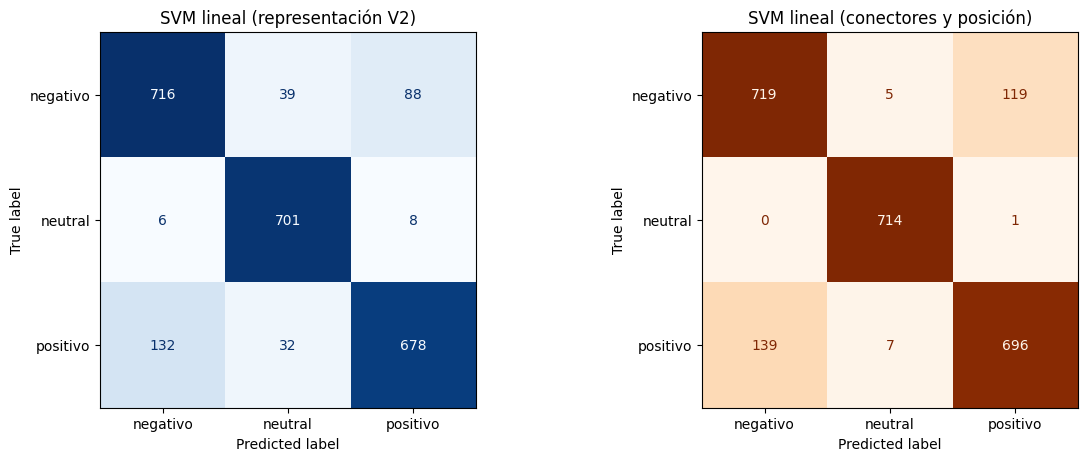

In [14]:
mejor_conectores = grid_conectores.best_estimator_

y_pred_conectores = mejor_conectores.predict(X_val)

print(f"Accuracy en validación: {accuracy_score(y_val, y_pred_conectores):.4f}\n")
print(classification_report(y_val, y_pred_conectores, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_base, cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("SVM lineal (representación V2)")

ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_conectores, cmap="Oranges", ax=axes[1], colorbar=False
)
axes[1].set_title("SVM lineal (conectores y posición)")

plt.show()

### 8.1. Comparación de los modelos

Se resumen los resultados de los modelos evaluados en este notebook junto con la referencia del modelo V2 de Regresión Logística. Se incluye la accuracy en entrenamiento para revisar posibles señales de sobreajuste, como en las prácticas del curso.

In [15]:
comparacion = pd.DataFrame([
    {
        "Modelo": "Regresión Logística V2 (referencia del equipo)",
        "Accuracy CV": 0.8536,
        "Accuracy entrenamiento": np.nan,
        "Accuracy validación": np.nan
    },
    {
        "Modelo": "SVM lineal (representación V2)",
        "Accuracy CV": grid_base.best_score_,
        "Accuracy entrenamiento": accuracy_score(y_train, mejor_base.predict(X_train)),
        "Accuracy validación": accuracy_score(y_val, y_pred_base)
    },
    {
        "Modelo": "SVM lineal (conectores y posición)",
        "Accuracy CV": grid_conectores.best_score_,
        "Accuracy entrenamiento": accuracy_score(y_train, mejor_conectores.predict(X_train)),
        "Accuracy validación": accuracy_score(y_val, y_pred_conectores)
    }
])

display(comparacion.round(4))

,Modelo,Accuracy CV,Accuracy entrenamiento,Accuracy validación
0,Regresión Logística V2 (referencia del equipo),0.8536,NaN,NaN
1,SVM lineal (representación V2),0.8595,0.9219,0.8729
2,SVM lineal (conectores y posición),0.8830,0.9999,0.8871


### 8.2. Interpretación de la comparación

El modelo con representación de conectores y posición obtuvo una accuracy de 88,71% en validación, frente al 87,29% del modelo base. La mejora que se vio en la validación cruzada se mantiene en datos que no se usaron para elegir los hiperparámetros.

Por clase, la mejora está sobre todo en `neutral`, cuyo F1-score pasa de 0,94 a 0,99. Las clases `negativo` y `positivo` se mantienen en valores similares (0,85 y 0,84). Es decir, mirar el resto de la reseña ayuda principalmente a reconocer cuándo una reseña no tiene una valoración clara. La confusión entre positivo y negativo sigue siendo la principal fuente de error.

La accuracy en entrenamiento del modelo con conectores es prácticamente del 100%, frente al 92,19% del modelo base. Esto indica que el modelo memoriza el conjunto de entrenamiento, lo cual es esperable por la gran cantidad de características que genera la nueva representación. Aun así, en validación cruzada y en validación le va mejor que al modelo base, por lo que esa capacidad extra no está afectando la generalización. Hay que tenerlo en cuenta para el puntaje privado de Kaggle.

## 9. Análisis de las características aprendidas

Al ser un modelo lineal, `LinearSVC` asigna un coeficiente a cada característica para cada clase. Se revisan los tokens compuestos de conector con mayor coeficiente para las clases positiva y negativa, con el fin de verificar si el modelo aprendió patrones coherentes con el análisis de errores.

Como en la práctica de Regresión Logística, los coeficientes deben interpretarse como asociaciones aprendidas por el modelo y no como relaciones causales. Además, su valor depende de las demás características incluidas en la representación.

In [16]:
rep_fit = mejor_conectores.named_steps["representacion"]
svm_fit = mejor_conectores.named_steps["modelo"]

# Nombres de las características de cada bloque de la FeatureUnion
nombres = []
for nombre_bloque, bloque in rep_fit.transformer_list:
    vectorizador = bloque[-1] if isinstance(bloque, Pipeline) else bloque
    nombres += [f"{nombre_bloque}__{t}" for t in vectorizador.get_feature_names_out()]

coefs = pd.DataFrame(svm_fit.coef_.T, index=nombres, columns=svm_fit.classes_)

# Solo tokens compuestos con conector (se excluyen los de posición pN__)
es_conector = (
    coefs.index.str.startswith("conectores__") &
    ~coefs.index.str.match(r"conectores__p\d+__")
)
coefs_conectores = coefs[es_conector].copy()
coefs_conectores.index = coefs_conectores.index.str.replace("conectores__", "", regex=False)

for clase in ["positivo", "negativo"]:
    print(f"Tokens con conector más asociados a '{clase}':")
    display(coefs_conectores[clase].sort_values(ascending=False).head(10).round(3).to_frame())

Tokens con conector más asociados a 'positivo':


,positivo
le__estrellas,0.781
le__cinco,0.764
la__maravilla,0.680
de__del,0.609
la__la,0.585
el__superó,0.583
por__de,0.561
la__buscando,0.554
termine__la,0.540
la__verdad,0.537


Tokens con conector más asociados a 'negativo':


,negativo
le__estrella,0.714
la__celular,0.634
la__problema,0.610
el__defraudó,0.590
me__pedí,0.587
se__mi,0.585
la__ni,0.582
la__el,0.580
la__no,0.573
me__porque,0.568


In [17]:
# Coeficientes de una misma palabra según el conector que la introduce
palabra = "feliz"

filas = coefs_conectores[coefs_conectores.index.str.endswith(f"__{palabra}")]

display(filas[["negativo", "neutral", "positivo"]].sort_values("positivo").round(3))

,negativo,neutral,positivo
de__feliz,0.282,-0.023,-0.187
me__feliz,0.205,-0.008,-0.181
al__feliz,0.050,-0.000,-0.040
debo__feliz,0.052,-0.010,-0.038
terminé__feliz,0.058,-0.048,-0.025
ademas__feliz,-0.019,0.000,-0.011
termine__feliz,0.052,-0.034,0.006
eso__feliz,-0.053,-0.025,0.012
la__feliz,-0.034,-0.000,0.017
en__feliz,-0.033,-0.032,0.065


### 9.1. Interpretación de las características

Los coeficientes muestran que el modelo aprendió a ponderar una misma palabra de forma distinta según la frase en la que aparece. En el caso de la palabra "feliz":

- Cuando aparece en frases que comienzan con "estoy" o "además", su coeficiente favorece claramente la clase `positivo`.
- Cuando aparece en frases que comienzan con "de" (por ejemplo, "De paso, estoy feliz con..."), su coeficiente favorece la clase `negativo`. En esas reseñas la expresión positiva suele ser un comentario secundario y la valoración principal es negativa.

Esto coincide con lo que se vio en el análisis de errores: con esta representación, un modelo lineal puede restarle peso a las opiniones secundarias sin reglas escritas a mano.

Al utilizar una sola palabra como conector, algunas marcas son generales (por ejemplo "la" o "el") y agrupan frases de distinto tipo. Por eso varios de los tokens con mayor coeficiente no son conectores como tal, y otros casos (como "me") son más difíciles de interpretar. Como en la práctica de Regresión Logística, estos coeficientes deben interpretarse como asociaciones aprendidas por el modelo, que dependen de las demás características incluidas, y no como relaciones causales.

## 10. Entrenamiento del modelo final

Se selecciona como modelo final el pipeline con representación de conectores y posición, con los hiperparámetros encontrados por `GridSearchCV`. Para aprovechar todos los datos etiquetados, se entrena una copia nueva del pipeline con las 12.000 reseñas.

También se entrena con todos los datos el modelo base (SVM con representación V2), para generar un envío adicional que permita medir en Kaggle el aporte de cada representación.

In [18]:
modelo_svm_final = clone(mejor_conectores)
modelo_svm_final.fit(X, y)

modelo_svm_base_final = clone(mejor_base)
modelo_svm_base_final.fit(X, y)

print("Modelos entrenados con", len(X), "reseñas")

Modelos entrenados con 12000 reseñas


## 11. Almacenamiento del modelo entrenado

Se guardan ambos pipelines mediante `joblib`, sin sobrescribir los modelos de los demás integrantes. El archivo contiene la transformación del texto, las representaciones TF-IDF y el clasificador.

Para cargar el modelo en otro entorno es necesario que el módulo `transformaciones.py` esté disponible, ya que el pipeline hace referencia a sus funciones.

Después de guardar, se carga el archivo y se verifica que produce las mismas predicciones que el pipeline original.

In [19]:
carpeta_modelos = raiz / "models"
carpeta_modelos.mkdir(exist_ok=True)

ruta_svm = carpeta_modelos / "svm_lineal_conectores.joblib"
ruta_svm_base = carpeta_modelos / "svm_lineal_v2.joblib"

joblib.dump(modelo_svm_final, ruta_svm)
joblib.dump(modelo_svm_base_final, ruta_svm_base)

# Verificar la carga
modelo_svm_cargado = joblib.load(ruta_svm)
modelo_svm_base_cargado = joblib.load(ruta_svm_base)

assert np.array_equal(
    modelo_svm_final.predict(X.iloc[:50]),
    modelo_svm_cargado.predict(X.iloc[:50])
)
assert np.array_equal(
    modelo_svm_base_final.predict(X.iloc[:50]),
    modelo_svm_base_cargado.predict(X.iloc[:50])
)

print("Modelos guardados y verificados:")
print(ruta_svm)
print(ruta_svm_base)

Modelos guardados y verificados:
C:\Users\julia\Proyecto-Machine-Learning\models\svm_lineal_conectores.joblib
C:\Users\julia\Proyecto-Machine-Learning\models\svm_lineal_v2.joblib


## 12. Generación de predicciones para Kaggle

Se generan las predicciones sobre las 3.000 reseñas de `eval.csv` con los modelos cargados desde disco. Antes de guardar cada archivo se verifica que tenga las columnas, los identificadores y la cantidad de registros exigidos por la competencia.

In [20]:
carpeta_submissions = raiz / "submissions"
carpeta_submissions.mkdir(exist_ok=True)

def generar_submission(modelo, nombre_archivo):
    predicciones = modelo.predict(eval_data["text"])

    submission = pd.DataFrame({
        "id": eval_data["id"],
        "answer": predicciones
    })

    # Verificar formato
    assert list(submission.columns) == list(sample.columns)
    assert submission["id"].equals(sample["id"])
    assert len(submission) == 3000
    assert submission["answer"].notna().all()
    assert set(submission["answer"]).issubset(set(y.unique()))

    ruta = carpeta_submissions / nombre_archivo
    submission.to_csv(ruta, index=False)

    print("Archivo:", ruta.name)
    print(submission["answer"].value_counts().to_string(), "\n")

    return submission

submission_svm = generar_submission(modelo_svm_cargado, "submission_svm_lineal_conectores.csv")
submission_svm_base = generar_submission(modelo_svm_base_cargado, "submission_svm_lineal_v2.csv")

Archivo: submission_svm_lineal_conectores.csv
answer
positivo    1087
negativo    1059
neutral      854 



Archivo: submission_svm_lineal_v2.csv
answer
negativo    1079
positivo     981
neutral      940 



In [21]:
# Coincidencia entre las predicciones de ambos envíos
coincidencia = (submission_svm["answer"] == submission_svm_base["answer"]).mean()
print(f"Las dos versiones coinciden en el {coincidencia:.2%} de las reseñas de evaluación")

Las dos versiones coinciden en el 89.87% de las reseñas de evaluación


## 13. Evaluación en Kaggle

Se realizaron dos envíos a la plataforma Kaggle con los archivos generados en la sección anterior. Ambos fueron aceptados correctamente.

| Envío | Modelo | Accuracy CV | Accuracy validación | Puntaje público Kaggle |
|---|---|---|---|---|
| `submission_regresion_logistica_v2.csv` | Regresión Logística V2 (referencia del equipo) | 85,36% | No calculada | 86,56% |
| `submission_svm_lineal_v2.csv` | SVM lineal, representación V2 | 85,95% | 87,29% | 85,67% |
| `submission_svm_lineal_conectores.csv` | SVM lineal, conectores y posición | 88,30% | 88,71% | 87,56% |

El modelo de SVM lineal con representación de conectores y posición obtuvo un puntaje público de 87,56%, el mejor resultado del equipo hasta el momento. Supera en aproximadamente 1 punto porcentual al 86,56% de la Regresión Logística V2 y en 1,89 puntos al SVM con la representación V2.

El puntaje público es algo inferior a la accuracy de validación cruzada (88,30%) y de validación (88,71%). Esto es coherente con la diferencia observada entre entrenamiento y validación: el modelo tiene una alta capacidad de memorización y su desempeño sobre datos nuevos puede ser ligeramente menor que el estimado.

Por otra parte, el SVM con la representación V2 obtuvo en Kaggle un puntaje inferior al de la Regresión Logística V2 (85,67% frente a 86,56%), aunque en validación cruzada había sido ligeramente superior (85,95% frente a 85,36%). Esto indica que las diferencias de menos de un punto entre esos dos clasificadores no son concluyentes y pueden deberse a la variabilidad del subconjunto público. En cambio, la mejora de la representación con conectores aparece en la validación cruzada, en la validación y en Kaggle, así que es el resultado más confiable del notebook.

Como el puntaje público se calcula solo con una parte de los datos de evaluación, el resultado en el puntaje privado puede ser algo distinto.

## 14. Conclusiones

Se desarrolló un clasificador de sentimientos basado en SVM lineal (`LinearSVC`), siguiendo el mismo procedimiento de validación utilizado por el equipo para la Regresión Logística.

En primer lugar, se reemplazó la Regresión Logística del modelo V2 por una SVM lineal, manteniendo la misma representación del texto (última oración con TF-IDF de palabras y caracteres). Con `C=0.2`, este modelo obtuvo una accuracy de 85,95% en validación cruzada y de 87,29% en validación, ligeramente superior a la Regresión Logística con la misma representación. La ponderación de clases no produjo diferencias relevantes, debido al desbalance leve del conjunto de datos.

El análisis de errores mostró que la confusión entre reseñas positivas y negativas se concentra en reseñas con dos opiniones opuestas, donde una de ellas se introduce con expresiones como "por otro lado", "de paso", "por cierto" o "eso sí". Usar solo la última oración no permite capturar esta estructura, que es justamente la dificultad que plantea el enunciado: el sentimiento global depende del orden y de los conectores.

Con base en este análisis, se construyó una representación que marca cada palabra con el inicio de la frase que la contiene y con la posición de esa frase dentro de la reseña, y se combinó con el TF-IDF del texto completo y la representación V2. Este modelo obtuvo una accuracy de 88,30% en validación cruzada y de 88,71% en validación, y la mejora más grande se dio en la clase `neutral`.

Se generaron dos envíos para Kaggle: el modelo base de SVM (`submission_svm_lineal_v2.csv`) y el modelo con conectores (`submission_svm_lineal_conectores.csv`). Ambos pipelines se almacenaron mediante `joblib` en la carpeta `models` y requieren el módulo `transformaciones.py` para ser cargados.

En Kaggle, el modelo con conectores obtuvo un puntaje público de 87,56%, el mejor del equipo hasta el momento, frente al 86,56% de la Regresión Logística V2 y el 85,67% del SVM con la representación V2. Por ser el envío con mejor resultado, este modelo (`svm_lineal_conectores.joblib`) es el candidato para la entrega en Bloque Neón.

Como limitación, el modelo final alcanza una accuracy cercana al 100% en entrenamiento, lo que indica una alta capacidad de memorización. Además, la confusión entre positivo y negativo sigue siendo la principal fuente de error, ya que una representación de bolsa de palabras, incluso con contexto de frase, no capta completamente la relación entre opiniones de signo contrario. Esto se podría abordar en la segunda parte del proyecto con modelos secuenciales.